# Homework: Langevin, Metropolis, MALA, and Hamiltonian Monte Carlo

**Student:** _replace with your name_  
**Date:** _replace with the submission date_

In this project you will tune four sampling algorithms on targets with anisotropy, curvature, and multiple modes. You will use distributional error and mixing diagnostics—not visual plausibility or acceptance alone—to decide whether sampling is successful.

Restart the kernel and run all cells once before using the interactive controls.

## Project structure

The implementations intentionally live in normal Python modules:

| File | Responsibility |
|---|---|
| `mcmc_homework/targets.py` | target distributions and exact reference samplers |
| `mcmc_homework/samplers.py` | RWMH, ULA, MALA, and HMC implementations |
| `mcmc_homework/metrics.py` | sliced-Wasserstein error, ESS, and diagnostics |
| `mcmc_homework/visualization.py` | trajectory, trace, ACF, and mode-ratio plots |
| `mcmc_homework/experiments.py` | reproducible runs and repeated-seed benchmarks |
| `mcmc_homework/widgets.py` | sliders and the Start button |
| `tests/` | numerical correctness tests |

Read the implementation files alongside this notebook. The notebook is an experiment and reporting surface, not the source of every function.

## 1. Four samplers

Let $\ell(x)=\log\pi(x)$ and $Z\sim\mathcal N(0,I)$.

| Method | Transition | Hyperparameters | Correction? |
|---|---|---|---|
| **RWMH** | $Y=X_k+\sigma Z$ | proposal scale $\sigma$ | symmetric MH ratio |
| **ULA** | $X_{k+1}=X_k+\eta\nabla\ell(X_k)+\sqrt{2\eta}Z$ | step $\eta$ | none; finite-step bias |
| **MALA** | propose the ULA transition | step $\eta$ | asymmetric MH ratio |
| **HMC** | simulate position and momentum by leapfrog | integrator step $\epsilon$, number of steps $L$ | Hamiltonian MH ratio |

HMC augments the state with momentum $p\sim\mathcal N(0,I)$ and uses

$$H(x,p)=-\ell(x)+\tfrac12p^\top p.$$

A leapfrog trajectory approximately conserves $H$. The proposal is accepted with

$$\alpha=\min\{1,\exp(H(x,p)-H(x',p'))\}.$$

Small steps can waste computation; large steps can cause ULA bias/divergence or MH/HMC rejection. Large $L$ lets HMC travel farther but costs more gradients and can create resonances. No hyperparameter or acceptance target is universally best.

## 2. Targets and metrics

The core tuning tasks use:

1. a tilted ill-conditioned Gaussian;
2. a thin banana-shaped target;
3. a 65:35 bimodal mixture.

A fourth **10:90 mixture** is a guided case study about rare-mode discovery.

The primary error is standardized sliced Wasserstein-1 distance (SWD) to an exact iid reference sample. Secondary diagnostics are effective sample size (ESS), ESS per 1,000 target evaluations, acceptance, and target-specific quantities such as mode mass and switches.

### ESS: how much independent information is in the chain?

**ESS stands for Effective Sample Size.** MCMC states are usually correlated: if the chain moves slowly, $Z_{t+1}$ resembles $Z_t$ and contributes little new information. ESS translates $N$ correlated retained states into the approximate number of independent samples with the same precision for estimating a scalar summary.

For a retained scalar chain $Z_1,\ldots,Z_N$, let $\rho_k=\operatorname{Corr}(Z_t,Z_{t+k})$ be its autocorrelation at lag $k$. Then

$$\operatorname{ESS}\approx\frac{N}{\underbrace{1+2\sum_{k\geq 1}\rho_k}_{\text{integrated autocorrelation time}}}.$$

- If the states are independent, $\rho_k\approx0$ and $\operatorname{ESS}\approx N$.
- If correlations remain positive over many lags, the denominator grows and $\operatorname{ESS}\ll N$.
- For example, 5,000 retained states with $\operatorname{ESS}=200$ contain roughly the same information for that summary as 200 independent samples.

In practice the infinite sum is estimated with a stable truncation rule. ESS is feature-specific, so this notebook evaluates several features (coordinates and a target-specific global feature) and reports the minimum. A mode indicator that never changes is assigned ESS zero. To compare computational efficiency, the notebook also reports

$$\operatorname{ESS/1k}=1000\,\frac{\operatorname{ESS}}{\text{number of target evaluations}}.$$

**Higher ESS is better**, but high ESS alone does not prove that the sampled distribution is correct. A chain can move efficiently inside one mode while completely missing another mode.

### SWD: how close is the sampled distribution to the target?

**SWD stands for Sliced Wasserstein Distance.** Directly comparing two two-dimensional clouds is difficult, so SWD looks at many one-dimensional *shadows*: project both clouds onto a direction $\theta_m$, compare their projected distributions, and average over directions.

For fixed unit directions $\theta_1,\ldots,\theta_M$, the standardized score used here is

$$\operatorname{SWD}(P,Q)=\frac{1}{M}\sum_{m=1}^{M}
\frac{W_1\!\left((\theta_m^\top)_\#P,(\theta_m^\top)_\#Q\right)}
{\operatorname{SD}_{Y\sim Q}(\theta_m^\top Y)},$$

where $P$ is the retained-chain distribution and $Q$ is an exact independent reference sample from the target. The one-dimensional Wasserstein distance

$$W_1(F,G)=\int_0^1\left|F^{-1}(u)-G^{-1}(u)\right|\,du$$

compares matching quantiles; intuitively, it measures how far probability mass must move to turn one projected distribution into the other. Dividing by the target standard deviation makes the score unitless and comparable across directions.

**Lower SWD is better.** Zero means an exact empirical match, although two finite correct samples normally have a small nonzero distance—the reported *reference noise floor*. SWD can detect incorrect means, spread, geometry, and missing or incorrectly weighted modes.

In short: **ESS measures sampling efficiency; SWD measures distributional accuracy. A good run needs both.**

### Explicit pass criterion

A target–method row passes only when **the worst SWD over all 20 fixed seeds in `BENCHMARK_SEEDS` is at or below its pair-specific threshold** and no ensemble diverges:

| target | RWMH | ULA | MALA | HMC |
|---|---:|---:|---:|---:|
| tilted Gaussian | $\leq 0.125$ | $\leq 0.305$ | $\leq 0.28$ | $\leq 0.105$ |
| banana | $\leq 0.205$ | $\leq 0.45$ | $\leq 1.2$ | $\leq 0.115$ |
| 65:35 mixture | $\leq 0.125$ | $\leq 0.83$ | $\leq 0.285$ | $\leq 0.645$ |
| 10:90 mixture (optional) | $\leq 0.125$ | $\leq 0.235$ | $\leq 0.34$ | $\leq 0.115$ |

**Calibration:** a prior audit tested chosen settings and their nearest slider values on 100 fresh seeds per pair; limits use the largest calibration/then-official SWD plus 10%, rounded up to 0.005. Another 50 seeds were held out: 1,597/1,600 exact/slider runs passed (three Gaussian MALA failures). These limits are unchanged; **grading now uses 20 fixed seeds.** A PASS is not proof of convergence. The 10:90 row is optional.

The numerical requirement is **PASS on all 12 core target–method rows**. Completing the homework also requires the six controlled investigations below, including your own screenshots and explanations. A passing table alone is not a complete submission. Every row receives the same total budget of **40,000 target evaluations per benchmark ensemble**, including burn-in and divided across all student-selected chains. One call to $\log\pi$ and one call to $\nabla\log\pi$ each count as one evaluation. Reference sampling, plotting, and metric calculations do not consume this sampling budget.

### What students tune for the submitted benchmark

Tune a separate setting for every target–method row:

| method | method-specific quantities | meaning |
|---|---|---|
| RWMH | proposal scale $\sigma$ | standard deviation of the Gaussian random-walk proposal |
| ULA | step size $\eta$ | strength of both the gradient drift and Langevin noise step |
| MALA | step size $\eta$ | scale of the Langevin proposal before MH correction |
| HMC | integrator step $\epsilon$ and leapfrog count $L$ | numerical step size and trajectory length/cost |

**Every row also tunes:** the number of independent chains $C\in\{1,\ldots,8\}$ and a burn-in fraction between 5% and 40%. This produces 12 submitted configurations: four methods for each of three core targets. RWMH, ULA, and MALA therefore have three tuned quantities per row; HMC has four.

### The resource-allocation trade-off

The 40,000-evaluation budget is split as evenly as possible across the chosen $C$ chains. The sampler automatically runs the longest chains that fit their shares. Approximate work per transition is:

| method | work per transition | approximate total transitions across all chains |
|---|---:|---:|
| RWMH | 1 density call | $40{,}000$ |
| ULA | 1 gradient call | $40{,}000$ |
| MALA | 1 density + 1 gradient call | $20{,}000$ |
| HMC | 1 density + $L$ gradient calls | $40{,}000/(L+1)$ |

Thus, more chains create more independent attempts to explore the target but make every chain shorter and repeat the warm-up cost. More burn-in may reduce initialization bias but leaves fewer retained samples. Increasing HMC's $L$ lengthens each trajectory but reduces the number of HMC transitions. These trade-offs are part of the homework.

The official evaluation repeats the **entire $C$-chain ensemble 20 times** using `BENCHMARK_SEEDS`. Each repeat gets 40,000 evaluations: **800,000 per row**, not a budget shared across seeds. Within a repeat with base seed $s$, chain $j=0,\ldots,C-1$ uses seed $s+101j$. All chains start from the supplied target start. Retained draws are combined within each repeat for SWD, never across repeats; ESS and switches are calculated within chains.

**Students may not change:** the 40,000-evaluation budget per repeat, the 20 benchmark base seeds, initial states, evaluation accounting, or SWD thresholds.

Burn-in removes an initial transient. It cannot fix discretization bias, mode trapping, or a poorly tuned integrator.

In [1]:
# %pip install -r requirements.txt
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from IPython.display import HTML, display

# The homework package may have changed while this notebook kernel
# remained open. Remove cached local modules before importing the
# current project API so rerunning this cell is sufficient.
for module_name in tuple(sys.modules):
    if module_name == "mcmc_homework" or module_name.startswith("mcmc_homework."):
        del sys.modules[module_name]

from mcmc_homework import (
    BENCHMARK_SEEDS,
    BENCHMARK_TARGET_EVAL_BUDGET,
    CORE_TARGET_KEYS,
    DEFAULT_SETTINGS,
    METHODS,
    SWD_PASS_THRESHOLDS,
    TARGETS,
    benchmark_all_settings,
    benchmark_results_html,
    benchmark_setting,
    build_sampling_lab,
    gradient_check_report,
    metrics_html,
    plot_sampling_run,
    plot_swd_convergence,
    run_experiment,
)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.18})

### Numerical implementation check

In [3]:
gradient_checks = gradient_check_report()
assert all(row["passed"] for row in gradient_checks), gradient_checks
display(HTML(
    "<table><tr><th>target</th><th>maximum gradient error</th><th>status</th></tr>"
    + "".join(
        f"<tr><td>{row['target']}</td><td>{row['max_abs_error']:.2e}</td><td>pass</td></tr>"
        for row in gradient_checks
    )
    + "</table>"
))

target,maximum gradient error,status
gaussian,7.96e-10,pass
banana,1.43e-10,pass
mixture,7.49e-10,pass
imbalanced_mixture,2.34e-10,pass


## 3. Read an HMC diagnostic plot

Orange is the burn-in path; blue points are retained states. The trace panel shows $x_1$ and $x_2$ over transitions. Running statistics expose slow convergence, and the ACF panel shows correlation among retained states.

This is a demonstration setting, not an answer key for the final fixed-budget benchmark.

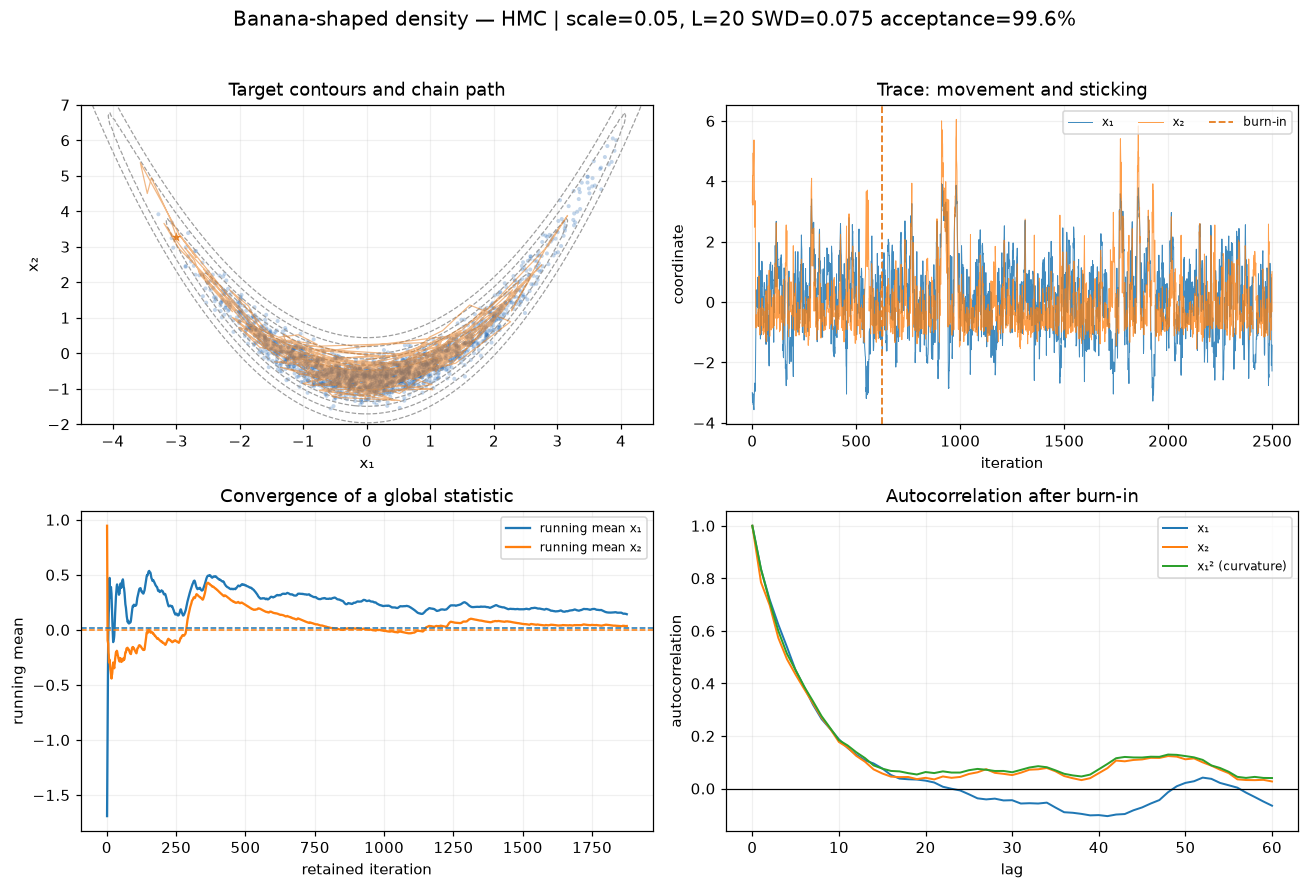

Metric,Value
Single plotted chain: SWD (lower is better),0.075
Official worst-repeat SWD target (20 benchmark seeds),≤ 0.115
Reference-sample SWD noise floor,≈ 0.030
Minimum ESS after burn-in,81.5
"Minimum ESS per 1,000 target evaluations",1.6
Acceptance rate,99.6%
residual-scale error,0.017
x₁ variance error,0.043


In [4]:
hmc_demo = run_experiment(
    "banana", "HMC", scale=0.05,
    n_steps=2500, burn_fraction=0.25, seed=11, n_leapfrog=20,
)
plot_sampling_run(hmc_demo)
plt.show()
display(HTML(metrics_html(hmc_demo)))

## 4. Interactive tuning lab

Choose target, method, scale, burn-in, chains $C$, and HMC's $L$, then press **Start sampling**. **Seed repeats** selects 1–20 repeats (default 3), using the first $N$ seeds from the benchmark's identical `BENCHMARK_SEEDS` list. Each repeat gets 40,000 evaluations, split across its chains; 20 repeats cost at most 800,000 calls.

**Fewer than 20 repeats is exploratory, not an official PASS.** At 20 repeats, the lab and benchmark give identical results for identical settings. Repeats test randomness; they are not extra chains and their samples are not pooled. Changing controls does not run sampling. Settings are remembered per target–method pair; a new pair inherits current values, clipped only to valid slider bounds.

**View traces** selects a completed repeat's paths and diagnostics without rerunning. The SWD plot shows every evaluated seed, highlighting the selected one; with more than six, the others are grey. The banner summarizes all evaluated repeats; the table describes only the selected seed. Compare the same seed in screenshots. Several chains trapped in one mode do not show global exploration.

In [5]:
# Dispose the previous widget when this cell is rerun.
if "lab" in globals():
    if hasattr(lab, "close"):
        lab.close()
    else:  # compatibility with a lab created before this update
        lab.run_button.on_click(lab._on_click, remove=True)
        lab.output.close()
        lab.ui.close()
lab = build_sampling_lab()
display(lab.ui)

## 5. Rare-mode experiments

In the lab, select the **10:90 mixture** and compare ULA with HMC at the fixed evaluation budget. Use your own runs and labelled screenshots to answer:

1. What left:right proportions do you obtain, compared with 10:90?
2. Can a plausible-looking cloud still have large SWD? Why?
3. How many mode switches occur? Why is one switch weak evidence of mixing?
4. Increase ULA's step: how do mode discovery, SWD, and finite-step bias change?
5. Reduce HMC's $L$ at fixed $\epsilon$: how does rare-mode discovery change?

**Your experiments and answers:** _replace this text._

## 6. Record and benchmark your settings

Record a justified choice for every row below. RWMH uses `scale = sigma`; ULA/MALA use `scale = eta`; HMC uses `scale = epsilon` plus `n_leapfrog = L`. The supplied values are starting guesses, not optimized answers. Keep a search log containing at least three distinct candidate configurations per row (at least 36 entries in total); report failures as well as improvements. You may search manually or with your own script.

For each candidate, record target, method, scale, $L$ if applicable, $C$, burn-in, repeat count, and worst-repeat SWD. Use fewer lab repeats for quick exploration, then compare your two strongest candidates per row on all 20 seeds. Retain per-repeat scores; a single displayed seed cannot establish PASS.

For every row, choose `scale`, `n_chains`, and `burn_fraction`; HMC also chooses `n_leapfrog`. Do not change the per-repeat budget, 20 fixed `BENCHMARK_SEEDS`, initial states, accounting, or thresholds. The table reports **PASS / TUNE MORE**. Each method's dashed plot limit matches its curve colour; curves need not decrease monotonically.

To check one candidate across the official repeats without rerunning all 12 rows, call `benchmark_setting(target_key, method, **candidate, seeds=BENCHMARK_SEEDS, target_eval_budget=BENCHMARK_TARGET_EVAL_BUDGET)`. Here `candidate` is a settings dictionary with the same fields as a row of `student_settings`. The returned pair is `(ensembles, summary)`; record `summary["worst_swd"]` in your log.

**Your search log and justification of the final candidates:** _insert your table here, or link to an included results file._

In [6]:
# TODO: select and justify all 12 configurations after exploration.
student_settings = {
    key: value.copy()
    for key, value in DEFAULT_SETTINGS.items()
    if key[0] in CORE_TARGET_KEYS
}
student_settings

{('gaussian', 'RWMH'): {'scale': 0.12, 'n_chains': 2, 'burn_fraction': 0.25},
 ('gaussian', 'ULA'): {'scale': 0.008, 'n_chains': 2, 'burn_fraction': 0.25},
 ('gaussian', 'MALA'): {'scale': 0.008, 'n_chains': 2, 'burn_fraction': 0.25},
 ('gaussian', 'HMC'): {'scale': 0.08,
  'n_leapfrog': 15,
  'n_chains': 2,
  'burn_fraction': 0.25},
 ('banana', 'RWMH'): {'scale': 0.18, 'n_chains': 2, 'burn_fraction': 0.25},
 ('banana', 'ULA'): {'scale': 0.002, 'n_chains': 2, 'burn_fraction': 0.25},
 ('banana', 'MALA'): {'scale': 0.003, 'n_chains': 2, 'burn_fraction': 0.25},
 ('banana', 'HMC'): {'scale': 0.05,
  'n_leapfrog': 20,
  'n_chains': 2,
  'burn_fraction': 0.25},
 ('mixture', 'RWMH'): {'scale': 0.9, 'n_chains': 2, 'burn_fraction': 0.25},
 ('mixture', 'ULA'): {'scale': 0.06, 'n_chains': 2, 'burn_fraction': 0.25},
 ('mixture', 'MALA'): {'scale': 0.08, 'n_chains': 2, 'burn_fraction': 0.25},
 ('mixture', 'HMC'): {'scale': 0.18,
  'n_leapfrog': 20,
  'n_chains': 2,
  'burn_fraction': 0.25}}

target,method,setting,mean ± SD SWD,worst / required,ESS/1k,accept,diverged,status
gaussian,RWMH,"σ=0.12; C=2, burn=25%",0.165 ± 0.108,0.400 / ≤ 0.125,1.1,75.3%,0,TUNE MORE
gaussian,ULA,"η=0.008; C=2, burn=25%",0.141 ± 0.081,0.351 / ≤ 0.305,1.6,N/A,0,TUNE MORE
gaussian,MALA,"η=0.008; C=2, burn=25%",0.223 ± 0.131,0.559 / ≤ 0.280,0.9,95.3%,0,TUNE MORE
gaussian,HMC,"ε=0.08, L=15; C=2, burn=25%",0.052 ± 0.028,0.112 / ≤ 0.105,8.3,97.8%,0,TUNE MORE
banana,RWMH,"σ=0.18; C=2, burn=25%",0.118 ± 0.065,0.315 / ≤ 0.205,1.6,73.4%,0,TUNE MORE
banana,ULA,"η=0.002; C=2, burn=25%",0.309 ± 0.230,1.104 / ≤ 0.450,0.5,N/A,0,TUNE MORE
banana,MALA,"η=0.003; C=2, burn=25%",0.335 ± 0.328,1.632 / ≤ 1.200,0.5,99.1%,0,TUNE MORE
banana,HMC,"ε=0.05, L=20; C=2, burn=25%",0.101 ± 0.048,0.218 / ≤ 0.115,2.7,99.6%,0,TUNE MORE
mixture,RWMH,"σ=0.9; C=2, burn=25%",0.110 ± 0.083,0.302 / ≤ 0.125,1.0,46.9%,0,TUNE MORE
mixture,ULA,"η=0.06; C=2, burn=25%",0.313 ± 0.241,1.046 / ≤ 0.830,3.5,N/A,0,TUNE MORE


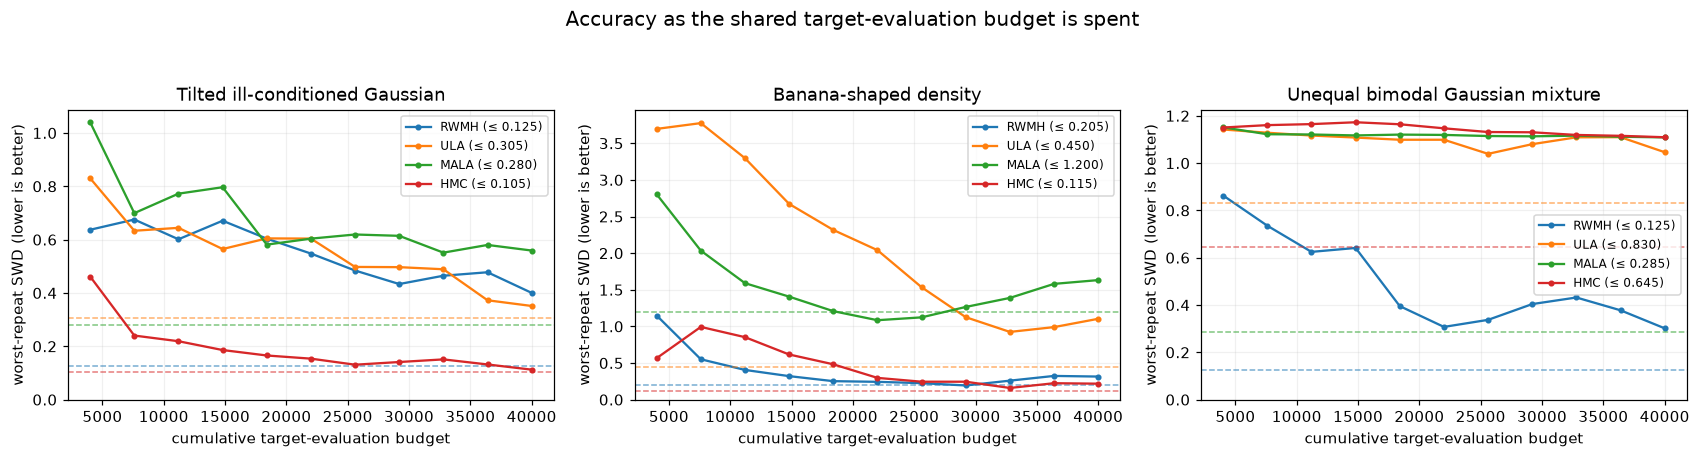

In [7]:
RUN_FULL_BENCHMARK = True  # set False only while doing quick exploration

if RUN_FULL_BENCHMARK:
    # Official submission evaluation: do not change these arguments.
    benchmark_results = benchmark_all_settings(
        student_settings,
        target_eval_budget=BENCHMARK_TARGET_EVAL_BUDGET,
        seeds=BENCHMARK_SEEDS,
    )
    display(HTML(benchmark_results_html(benchmark_results)))
    plot_swd_convergence(benchmark_results)
    plt.show()
else:
    print("Set RUN_FULL_BENCHMARK = True to see the official PASS / TUNE MORE result.")

## 7. Controlled investigations

Complete all six. Change **one parameter at a time**; keep other settings, initial states, and budget fixed. Use **View traces: seed 11** for comparisons.

For each investigation submit:

- A table of all runs: settings, worst-repeat SWD, displayed-seed SWD, ESS/1k, acceptance, states/retained states per chain, and failures. For mixtures, add mode-mass error and switches.
- Brief answers to the questions; explain unexpected results too.
- The requested screenshots of **your lab plots and metrics**, captioned with settings and seed. Save each before rerunning; use matching axes. Embed images or include a portable `screenshots/` folder.

### Investigation 1 — RWMH: proposal scale

On the **Gaussian and 65:35 mixture**, test small, medium, and large $\sigma$.

1. How do acceptance, repeated states, movement, and ACF change? Can high acceptance coexist with poor SWD or ESS?
2. How do the Gaussian's long and narrow axes affect proposals and rejections?
3. Does larger $\sigma$ improve mode discovery? At what cost? Which scale works best for each target?

**Screenshots:** small/large $\sigma$ on both targets (4).

**Results and answers:** _replace this text._

### Investigation 2 — ULA: step size

On the **Gaussian and banana**, test small, medium, and large $\eta$. Record divergence; if it occurs, also try a nearby smaller step.

1. How do drift, noise $\sqrt{2\eta}$, traces, and ACF change?
2. Can ESS improve while SWD worsens? Use covariance/residual-scale error to assess shape. Can your evidence separate bias from finite-sample error?
3. Derive the Gaussian stability condition $\eta<2\lambda_{\min}(\Sigma)$. Does stability ensure accuracy? Compare with your runs.

**Screenshots:** small/large $\eta$ on both targets (4), including any divergence warning.

**Results and answers:** _replace this text._

### Investigation 3 — MALA: Metropolis correction

On the **banana**, compare ULA and MALA at the same small, medium, and aggressive $\eta$ (6 runs). Matching earlier ULA runs may be reused.

1. Why do identical proposals produce different clouds and traces? How do MALA acceptance and repeated states change with $\eta$?
2. Does correction guarantee good finite-budget sampling? Compare SWD, ESS/1k, and states per chain, accounting for density/gradient costs.
3. Where does correction matter most? Which method/step offers the better trade-off?

**Screenshots:** ULA/MALA at the same aggressive step, side by side (2).

**Results and answers:** _replace this text._

### Investigation 4 — HMC: trajectory length and step size

On the **banana and 65:35 mixture**, compare $L$ in 1–3, 8–15, and 25–40 at fixed $\epsilon$. Record $T=\epsilon L$. On one target, also compare small/large $\epsilon$ at fixed $L$.

1. Do longer trajectories improve travel or mode switching enough to offset fewer proposals? Observe rejection or returns near the starting point?
2. How does changing $\epsilon$ differ from changing $L$? Distinguish leapfrog steps from retained chain states.
3. Which $(\epsilon,L)$ best balances SWD, acceptance, and ESS/1k?

**Screenshots:** low/high $L$ on both targets (4), plus small/large $\epsilon$ (2).

**Results and answers:** _replace this text._

### Investigation 5 — Number of chains

Compare $C=1,2,4,8$ for **ULA and HMC** on the **Gaussian and 65:35 mixture**. Keep scale, $L$, and burn-in fixed; record all 16 runs.

1. How do shorter chains trade off against independent restarts? Compare retained lengths and initialization effects at fixed burn-in fraction.
2. Why might many chains starting at the same point still miss a mode? Compare pooled SWD, individual traces, and switches.
3. Does your preferred $C$ work across all 20 benchmark seeds? How does it depend on method and target?

**Screenshots:** $C=1$ versus $C=8$ for two contrasting pairs, including all traces (4).

**Results and answers:** _replace this text._

### Investigation 6 — Burn-in and seed sensitivity

For **two contrasting target–method pairs**, compare 5%, 20%, and 40% burn-in with everything else fixed.

1. Why should the paths stay identical? How do retained counts, SWD, and ESS/1k change?
2. When does discarding states help or waste information? Can it fix a missing mode or ULA bias?
3. Does a promising setting perform worse on another seed? Inspect both with **View traces**; if not, compare your two best candidates. Why does PASS not prove convergence or method superiority?

**Screenshots:** low/high burn-in for both pairs (4). Include your final **12/12 PASS** table, SWD-budget plot, and Section 6 search log.

**Results and answers:** _replace this text._

## Submission checklist

- [ ] I inspected the separate implementation modules.
- [ ] I tuned method scale, chain count, and burn-in for all 12 rows; I also tuned $L$ for HMC.
- [ ] I ran the unchanged 40,000-evaluation-per-repeat benchmark with all 20 fixed base seeds.
- [ ] Every row in the benchmark table says **PASS** (12/12).
- [ ] I reported mean $\pm$ SD and worst-repeat SWD.
- [ ] My search log contains at least three candidates per row, including full benchmarks for the two strongest.
- [ ] I interpreted the SWD-over-target-evaluation-budget figure.
- [ ] I interpreted acceptance, ESS/target-evaluation cost, and task diagnostics.
- [ ] I completed the 10:90 rare-mode case-study questions.
- [ ] I completed all six controlled investigations with results tables and explanations.
- [ ] I inserted my own labelled screenshots for every requested comparison, including unsuccessful runs.
- [ ] My images are embedded as attachments or included in a portable `screenshots/` directory.
- [ ] I included the final benchmark table and convergence figure, then restarted the kernel and ran all cells before submission.